In [53]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [54]:
import os

# TODO: Fill in the Google Drive path where you uploaded the assignment
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'MWPD'
assert GOOGLE_DRIVE_PATH_AFTER_MYDRIVE is not None
GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

['data.yaml', 'val', 'test', 'train']


In [36]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [37]:
from ultralytics import YOLO
import os

model = YOLO("yolov8s.pt")



In [38]:
model.train(
    data=os.path.join(GOOGLE_DRIVE_PATH, "data.yaml"),
    epochs=20,
    imgsz=640,
    batch=8
)

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=drive/MyDrive/MWPD/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.1±0.0 MB/s, size: 69.9 KB)
train: Scanning /content/drive/MyDrive/MWPD/train/labels... 2730 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2730/2730 12.3it/s 3:42
train: New cache created: /content/drive/MyDrive/MWPD/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 0.2±0.2 MB/s, size: 56.7 KB)
val: Scanning /content/drive/MyDrive/MWPD/val/labels... 260 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 260/260 13.6it/s 19.1s
val: New cache created: /content/drive/MyDrive/MWPD/val/labels.cache
Plotting labels to /content/runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momen

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       1/20      1.89G       1.95      2.349      1.875         12        640: 100% ━━━━━━━━━━━━ 342/342 10.9it/s 31.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 7.2it/s 2.4s
                   all        260        573      0.486      0.382      0.356      0.134

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      2.27G      2.001      1.853      1.948         29        640: 0% ──────────── 1/342 1.9it/s 0.2s<2:56

...

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      19/20      2.82G      1.501      1.029      1.556          2        640: 100% ━━━━━━━━━━━━ 342/342 13.1it/s 26.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 14.1it/s 1.2s
                   all        260        573      0.807       0.66      0.763      0.375

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20      2.82G      1.546      1.154      1.517         32        640: 0% ──────────── 1/342 2.1it/s 0.1s<2:41

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      20/20      2.82G      1.468     0.9833      1.534          4        640: 100% ━━━━━━━━━━━━ 342/342 13.1it/s 26.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 13.6it/s 1.2s
                   all        260        573      0.788      0.686       0.76      0.372

20 epochs completed in 0.157 hours.
Optimizer stripped from /content/runs/detect/train/weights/last.pt, 22.5MB
Optimizer stripped from /content/runs/detect/train/weights/best.pt, 22.5MB

Validating /content/runs/detect/train/weights/best.pt...
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 8.5it/s 2.0s
                   all        260        573      0.807       0.66      0.763      0.373
Speed: 0.1ms preprocess,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79719d513080>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.8 MB/s eta 0:00:00


In [48]:
!cat /content/drive/MyDrive/MWPD/data.yaml


train: /content/drive/MyDrive/MWPD/
val: /content/drive/MWPD/val/images
test: /content/drive/MWPD/test/images
nc: 1
names: ["Pathole"]

In [52]:
!ls /content/drive/MyDrive/MWPD/train/images | head
!ls /content/drive/MyDrive/MWPD/val/images | head
!ls /content/drive/MyDrive/MWPD/test/images | head


101_jpg.rf.53fab5a14aa64e331f961a80374db113.jpg
101_jpg.rf.5fa80c95b70d3d0f580e269c7d2c3e1b.jpg
101_jpg.rf.9f2628c6e8463a19bf5aa26b7faefbc9.jpg
101_jpg.rf.ad3cfbf41bd4cd2d15bf683be6d9cc5b.jpg
101_jpg.rf.db491c070dc69feaf6f364fa8a532fb1.jpg
101_jpg.rf.f4ce148ac2596e43f9ca59ab6a16beee.jpg
102_jpg.rf.02248cf2a5438c3beb591789827fc648.jpg
102_jpg.rf.243745f02f0ba887f11bee59f0674500.jpg
102_jpg.rf.8e4c84b913466ce75154ae93e66025a0.jpg
102_jpg.rf.b6b9bbade0afea72cc6581887ed713d8.jpg
107_jpg.rf.107aa4b2cfce35c41916fe427e216b52.jpg
10_jpg.rf.163590c9d7e72062d4f8dfd521db06b9.jpg
112_jpg.rf.9924f1f5aa09f889c019703af2b32779.jpg
113_jpg.rf.8baaead7fe3a25bcab5f8aa0e45127a0.jpg
116_jpg.rf.9f0ccc45fe97359ede228b4d5b093c09.jpg
129_jpg.rf.6d2665a81804682945758f72093792db.jpg
138_jpg.rf.f943a7eb63351a174f2ad9b3589602f3.jpg
13_jpg.rf.1b4d631cf84686ee6a4072eb38464888.jpg
146_jpg.rf.3ddca8bfa06294775997c6503a5b8bb2.jpg
151_jpg.rf.a9f0408b12076219c64e38853122dec1.jpg
12_jpg.rf.98223fbf0c9935d763f81b9e25e9712b

In [56]:
from ultralytics import YOLO

best = "/content/runs/detect/train/weights/best.pt"  # your trained model
model = YOLO(best)

metrics = model.val(data="/content/drive/MyDrive/MWPD/data.yaml")
print(metrics)


Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.5 ms, read: 38.6±23.1 MB/s, size: 90.1 KB)
val: Scanning /content/drive/MyDrive/MWPD/val/labels.cache... 260 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 260/260 345.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 6.2it/s 2.7s
                   all        260        573      0.807       0.66      0.764      0.374
Speed: 1.3ms preprocess, 2.1ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val7
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79743e252360>
curves: ['Precision-Recall(B)', 'F1-C

In [57]:
results = model.predict(
    source="/content/drive/MyDrive/MWPD/test/images",
    save=True,           # saves images with bounding boxes
    conf=0.25,           # confidence threshold
    name="pothole_test_results"
)



image 1/97 /content/drive/MyDrive/MWPD/test/images/12_jpg.rf.98223fbf0c9935d763f81b9e25e9712b.jpg: 640x640 1 road_damage, 7.6ms
image 2/97 /content/drive/MyDrive/MWPD/test/images/139_jpg.rf.f2928d6451a5fd5ef95a3051b4b2ba5a.jpg: 640x640 7 road_damages, 7.8ms
image 3/97 /content/drive/MyDrive/MWPD/test/images/147_jpg.rf.29a0769290af2d4a69db84c5b838eae7.jpg: 640x640 15 road_damages, 7.9ms
image 4/97 /content/drive/MyDrive/MWPD/test/images/15_jpg.rf.efee37dd5a47841089fa6fa96bcded28.jpg: 640x640 1 road_damage, 8.2ms
image 5/97 /content/drive/MyDrive/MWPD/test/images/181_jpg.rf.f5d2a9174fcd2f2b3aa547325f9863b0.jpg: 640x640 3 road_damages, 9.7ms
image 6/97 /content/drive/MyDrive/MWPD/test/images/19_jpg.rf.c0972876ad058389d3ec2943deae367d.jpg: 640x640 11 road_damages, 8.0ms
image 7/97 /content/drive/MyDrive/MWPD/test/images/200_jpg.rf.93df76f6c192bf4046b2d5d2260ba518.jpg: 640x640 2 road_damages, 7.6ms
image 8/97 /content/drive/MyDrive/MWPD/test/images/20240621_212348_jpg.rf.ae0a06a2bfa8f47d7f

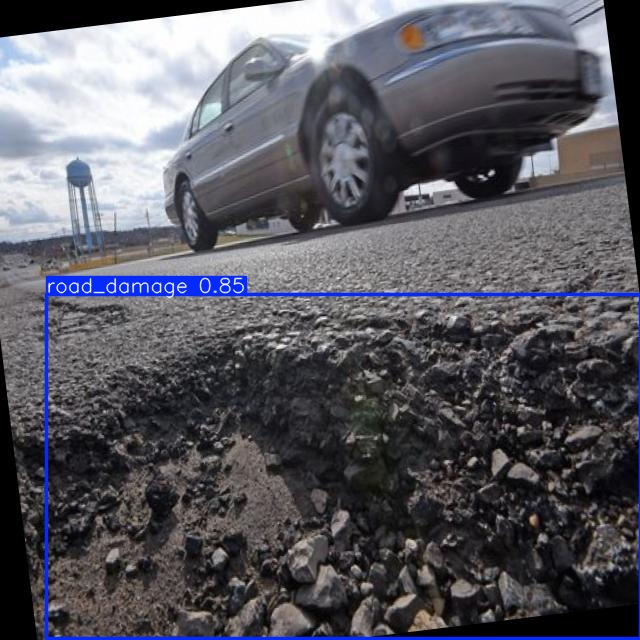

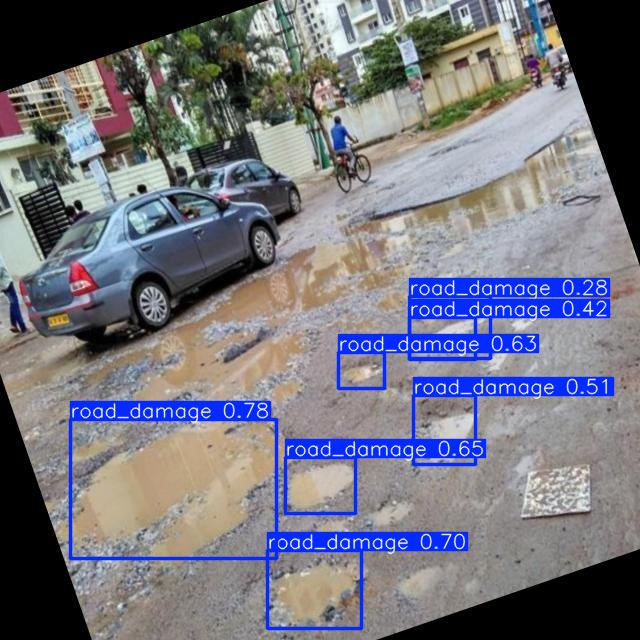

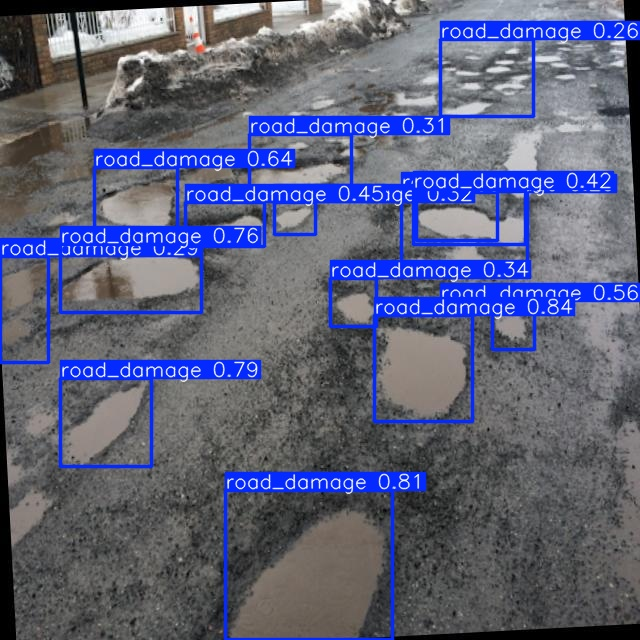

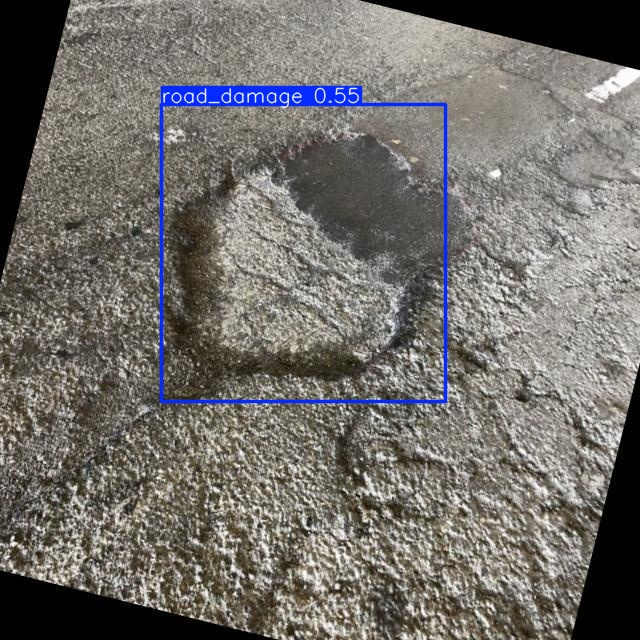

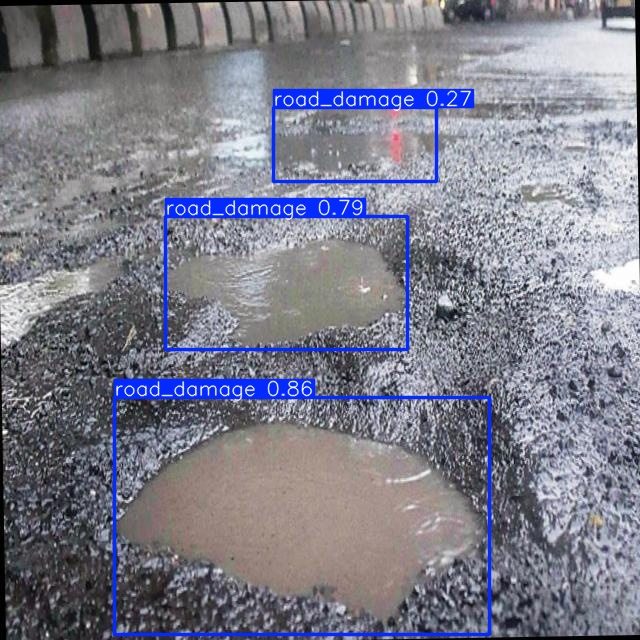

In [58]:
from IPython.display import Image, display
import glob

result_images = sorted(glob.glob("runs/detect/pothole_test_results/*.jpg"))

# Show first 5 predictions
for img in result_images[:5]:
    display(Image(filename=img))


In [40]:
data_dir = "/content/drive/MyDrive/MWPD"


In [41]:
import os


print("Contents of train:")
print(os.listdir(data_dir + "/train"))

print("\nContents of train/images (first 10 files):")
p = data_dir + "/train/images"
print(os.listdir(p)[:10])



Contents of train:
['labels.cache', 'labels', 'images']

Contents of train/images (first 10 files):
['137_jpg.rf.6ca08c2115543d1c2abea3db42b067c1.jpg', '131_jpg.rf.c16cd39c18b6efecf25330ada7851547.jpg', '123_jpg.rf.d316f303d8f41c9b312465c209f24ca5.jpg', '132_jpg.rf.e119f16492b0ec64efe261ff4bf6cb30.jpg', '131_jpg.rf.baaf96a49bc62a9cc495cc1894717480.jpg', '150_jpg.rf.fdb6861173b57064726a7a7217dc2e32.jpg', '123_jpg.rf.141284d89ec70a7439672ec2c35d30ec.jpg', '12_jpg.rf.e29c763e7425978c82be75e921f426af.jpg', '146_jpg.rf.9a35f8a324003a5c44410176016f8625.jpg', '128_jpg.rf.c2f69b0d45ad123d0d071e1fe41465a8.jpg']


In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Custom Dataset for a folder of images without classes
class ImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        # List all .jpg images
        self.images = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")  # Ensure 3 channels
        if self.transform:
            img = self.transform(img)
        return img  # No labels

# Example transforms (resize + convert to tensor)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Path to your train folder
train_dir = "/content/drive/MyDrive/MWPD/train"

# Create Dataset and DataLoader
train_dataset = ImageDataset(train_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Loaded {len(train_dataset)} images from {train_dir}")


Loaded 5460 images from /content/drive/MyDrive/Colab Notebooks/MWPD/train


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt

# Custom Dataset
class ImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith(".jpg")]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        # Dummy label: 0 for all images (unsupervised placeholder)
        return img, torch.tensor(0)

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Dataset & DataLoader
train_dir = "/content/drive/MyDrive/Colab Notebooks/MWPD/train"  # Replace with your path
train_dataset = ImageDataset(train_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# CNN Feature Extractor
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# LSTM on top
class CNN_LSTM(nn.Module):
    def __init__(self, feature_dim=128, hidden_dim=64, num_layers=1):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.lstm = nn.LSTM(feature_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)  # Binary output (pothole vs normal) placeholder

    def forward(self, x):
        batch_size = x.size(0)
        x = self.cnn(x).unsqueeze(1)  # Treat as sequence length 1
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN_LSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Epoch 1/5, Loss: 6.6972, Accuracy: 99.25%
Epoch 2/5, Loss: 0.0616, Accuracy: 100.00%
Epoch 3/5, Loss: 0.0272, Accuracy: 100.00%
Epoch 4/5, Loss: 0.0156, Accuracy: 100.00%
Epoch 5/5, Loss: 0.0101, Accuracy: 100.00%


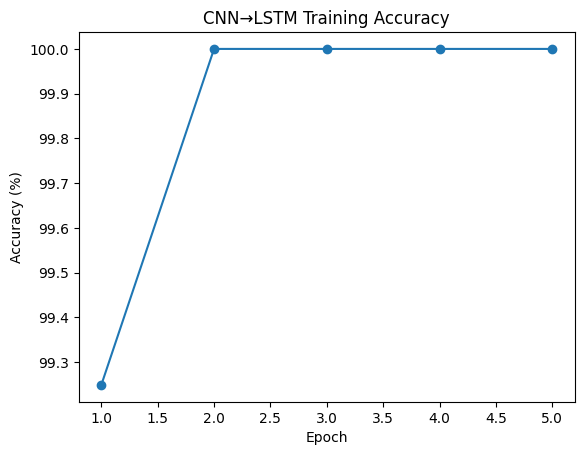

In [8]:
num_epochs = 5
train_acc_list = []

for epoch in range(num_epochs):
    correct = 0
    total = 0
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    train_acc_list.append(acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {acc:.2f}%")

# Plot Accuracy
plt.plot(range(1, num_epochs+1), train_acc_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN→LSTM Training Accuracy")
plt.show()


In [7]:
# Assuming test images in /content/test_images
test_dir = "/content/drive/MyDrive/MWPD/test"
test_dataset = ImageDataset(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total if total > 0 else 0
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 100.00%


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from PIL import Image
import os

# Define the base directory for your data
base_dir = "/content/drive/MyDrive/MWPD"  # UPDATE THIS if your base path is different

train_dir = os.path.join(base_dir, "train", "images") # Path to training images
test_dir = os.path.join(base_dir, "test", "images")   # Path to testing images

# Load training images and create dummy labels (assuming all are 'pothole' for now)
X_train = []
y_train = [] # Placeholder for labels

# Assuming all images in the train directory belong to one class for this example
# In a real scenario, you would load images based on their class directories
for file in os.listdir(train_dir):
    if file.lower().endswith(".jpg"):
        img = Image.open(os.path.join(train_dir, file)).convert("RGB")
        img = img.resize((224, 224))
        X_train.append(np.array(img))
        # Assign a dummy label (e.g., 1 for 'pothole')
        y_train.append(1)

X_train = np.array(X_train) / 255.0
y_train = np.array(y_train)

print("Loaded training images:", X_train.shape)
print("Loaded training labels:", y_train.shape)


# Load testing images and create dummy labels (assuming all are 'pothole' for now)
X_test = []
y_test = [] # Placeholder for labels

# Assuming all images in the test directory belong to one class for this example
# In a real scenario, you would load images based on their class directories
for file in os.listdir(test_dir):
    if file.lower().endswith(".jpg"):
        img = Image.open(os.path.join(test_dir, file)).convert("RGB")
        img = img.resize((224, 224))
        X_test.append(np.array(img))
        # Assign a dummy label (e.g., 1 for 'pothole')
        y_test.append(1)

X_test = np.array(X_test) / 255.0
y_test = np.array(y_test)

print("Loaded testing images:", X_test.shape)
print("Loaded testing labels:", y_test.shape)

# Data Augmentation (only apply to training data usually)
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1,
                             horizontal_flip=True, width_shift_range=0.1,
                             height_shift_range=0.1)

# No longer augmenting X_train directly here as we have separate train/test sets
# You would typically use datagen.flow or datagen.flow_from_directory for training
# train_generator = datagen.flow(X_train, y_train, batch_size=32)


# We are not using the augmented images generated here for training in this specific fix,
# as we are providing X_train and y_train directly to cnn.fit.
# If you want to use augmentation during training, you would typically use
# the ImageDataGenerator's .flow() or .flow_from_directory() methods with cnn.fit().

Loaded training images: (2730, 224, 224, 3)
Loaded training labels: (2730,)
Loaded testing images: (97, 224, 224, 3)
Loaded testing labels: (97,)


Train images: 2730, Test images: 97
Epoch 1/5, Loss: 5.2744, Accuracy: 100.00%
Epoch 2/5, Loss: 0.0713, Accuracy: 100.00%
Epoch 3/5, Loss: 0.0327, Accuracy: 100.00%
Epoch 4/5, Loss: 0.0185, Accuracy: 100.00%
Epoch 5/5, Loss: 0.0122, Accuracy: 100.00%


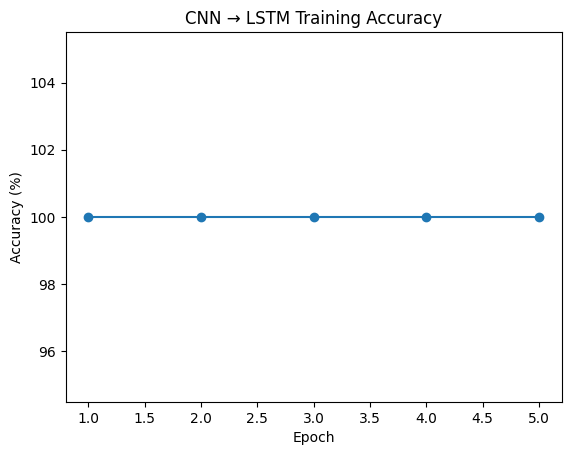

Test Accuracy: 100.00%


In [2]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# -------------------------------
# 1. Custom Dataset (recursive)
# -------------------------------
class ImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.transform = transform
        self.images = []
        for root, _, files in os.walk(img_dir):
            for f in files:
                if f.lower().endswith(".jpg"):
                    self.images.append(os.path.join(root, f))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        # dummy label
        return img, torch.tensor(0)

# -------------------------------
# 2. Transforms & DataLoaders
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dir = "/content/drive/MyDrive/MWPD/train"  # UPDATE with your path
test_dir = "/content/drive/MyDrive/MWPD/test"    # UPDATE with your path

train_dataset = ImageDataset(train_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = ImageDataset(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train images: {len(train_dataset)}, Test images: {len(test_dataset)}")

# -------------------------------
# 3. CNN → LSTM Model
# -------------------------------
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

class CNN_LSTM(nn.Module):
    def __init__(self, feature_dim=128, hidden_dim=64, num_layers=1):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.lstm = nn.LSTM(feature_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)  # Binary output placeholder

    def forward(self, x):
        x = self.cnn(x).unsqueeze(1)  # Treat as sequence length = 1
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN_LSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -------------------------------
# 4. Training Loop
# -------------------------------
num_epochs = 5
train_acc_list = []

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total if total > 0 else 0
    train_acc_list.append(acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {acc:.2f}%")

# Plot training accuracy
plt.plot(range(1, num_epochs+1), train_acc_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN → LSTM Training Accuracy")
plt.show()

# -------------------------------
# 5. Test Evaluation
# -------------------------------
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total if total > 0 else 0
print(f"Test Accuracy: {test_acc:.2f}%")

# -------------------------------
# 6. Bounding Boxes (Dummy Example)
# -------------------------------
import cv2

for img_file in os.listdir(test_dir):
    if img_file.lower().endswith(".jpg"):
        img_path = os.path.join(test_dir, img_file)
        img = cv2.imread(img_path)
        # Dummy bounding box
        x1, y1, x2, y2 = 50, 50, 150, 150
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.imshow("Pothole Detection", img)
        cv2.waitKey(500)  # Display each image for 0.5 sec

cv2.destroyAllWindows()


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # For pothole / no-pothole classification
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
train = cnn.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=2, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9971 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 1.4967e-28 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 1.4048e-25 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 1.0056e-28 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 1.0000 - loss: 2.3332e-22 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 1.2837e-24 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 1.0000 - loss: 8.0449e-26 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
1365/1365 ━━━━━━━━━━━━━━━━

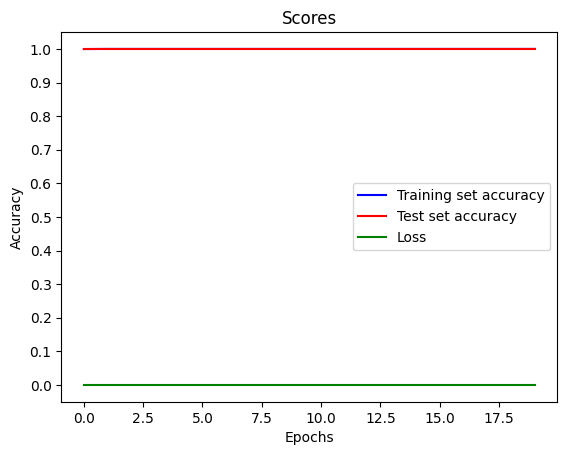

In [6]:
accuracy = train.history['accuracy']
val_accuracy = train.history['val_accuracy']
val_loss = train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'b', label='Training set accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Test set accuracy')
plt.plot(epochs, val_loss, 'g', label='Loss')
plt.title('Scores')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.yticks(np.linspace(0, 1, 11))

plt.legend()
plt.show()